In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('vnstock_listing_companies.csv')
df.head()

,ticker,exchange,shortName,industry,industryEn,establishedYear,noEmployees,noShareholders,foreignPercent,website,stockRating,outstandingShare,issueShare,companyType,monthlyRecords
0,CMV,HOSE,Thương nghiệp Cà Mau,Bán lẻ,Retail,1980.0,666.0,583.0,0.002,http://www.tncm.com.vn,2.8,18.2,18.2,CT,CMV.csv
1,COM,HOSE,Vật tư Xăng dầu,Bán lẻ,Retail,2000.0,0.0,395.0,0.003,http://comeco.vn,2.6,14.1,14.1,CT,COM.csv
2,DHT,HNX,Dược phẩm Hà Tây,Bán lẻ,Retail,2001.0,795.0,749.0,0.271,http://www.hataphar.com.vn,2.8,26.4,26.4,CT,DHT.csv
3,DGW,HOSE,Thế Giới Số,Bán lẻ,Retail,2003.0,612.0,1228.0,0.259,https://digiworld.com.vn,2.9,163.1,163.2,CT,DGW.csv
4,TTH,HNX,TM và DV Tiến Thành,Bán lẻ,Retail,2003.0,21.0,1452.0,0.003,http://www.tienthanhjsc.vn,NaN,37.4,37.4,CT,TTH.csv


# Câu 1

In [3]:
column_headers = list(df.columns.values)
print("Danh sách các cột :", column_headers)

so_dong = len(df)
print('Số dòng dữ liệu của bảng:',so_dong)

Danh sách các cột : ['ticker', 'exchange', 'shortName', 'industry', 'industryEn', 'establishedYear', 'noEmployees', 'noShareholders', 'foreignPercent', 'website', 'stockRating', 'outstandingShare', 'issueShare', 'companyType', 'monthlyRecords']
Số dòng dữ liệu của bảng: 1155


# Câu 2

In [4]:
def find_stock(mssv: str):
    index = int(mssv[8:]) % 1000
    ticker = df['ticker'].iloc[index]
    return index, ticker

In [5]:
mssv = '050611231449'
index, ticker = find_stock(mssv)
print('Kết quả cổ phiếu số thứ tự', index, ':', ticker)

Kết quả cổ phiếu số thứ tự 449 : HTG


# Câu 3

In [6]:
companies_filter = df[['ticker', 'shortName', 'monthlyRecords']].iloc[index]
companies_filter

ticker                        HTG
shortName         Dệt may Hòa Thọ
monthlyRecords            HTG.csv
Name: 449, dtype: object

# Câu 4

In [7]:
URL = 'transaction/' + str(ticker) +'.csv'
df_FTM = pd.read_csv(URL)

In [8]:
lst = []
for index, month in enumerate(df_FTM['time']):
    if int(month[5:7]) == 8 or int(month[5:7]) == 9:
        lst.append(index)

df_ = df_FTM[min(lst) : max(lst) + 1].reset_index().drop(columns = ['index'])

print('Số lượng giao dịch từ tháng 8 tới tháng 9:',len(df_),
    '\nGiá Close cao nhất từ tháng 8 tới tháng 9:' ,df_.describe()['close']['max'],
    '\nGiá Close trung bình từ tháng 8 tới tháng 9:' ,df_.describe()['close']['mean'],
    '\nGiá Close thấp nhất từ tháng 8 tới tháng 9:' ,df_.describe()['close']['min'])

Số lượng giao dịch từ tháng 8 tới tháng 9: 42 
Giá Close cao nhất từ tháng 8 tới tháng 9: 32800.0 
Giá Close trung bình từ tháng 8 tới tháng 9: 28880.95238095238 
Giá Close thấp nhất từ tháng 8 tới tháng 9: 26700.0


# Câu 5

In [9]:
info1 = []
for close, open in zip(df_['close'], df_['open']):
    if close > open:
        info1.append(1)
    elif close < open:
        info1.append(-1)
    else:
        info1.append(0)

df_['Info01'] = info1
df_.head()

,time,open,high,low,close,volume,ticker,Info01
0,2023-08-01,27000,27800,27000,27300,30200,HTG,1
1,2023-08-02,27100,27400,27100,27400,18900,HTG,1
2,2023-08-03,27500,27500,27200,27300,18800,HTG,-1
3,2023-08-04,27300,27500,27300,27500,19900,HTG,1
4,2023-08-07,27300,27600,27200,27400,70000,HTG,1


# Câu 6

In [10]:
close_prev, close_next = df_FTM['close'][min(lst) - 1 : max(lst)], df_FTM['close'][min(lst) : max(lst) + 1]

In [11]:
info2 = []
for prev, next in zip(close_prev, close_next):
    if prev > next:
        info2.append(-1)
    elif prev < next:
        info2.append(1)
    else:
        info2.append(0)

df_['Info02'] = info2
df_.head()

,time,open,high,low,close,volume,ticker,Info01,Info02
0,2023-08-01,27000,27800,27000,27300,30200,HTG,1,0
1,2023-08-02,27100,27400,27100,27400,18900,HTG,1,1
2,2023-08-03,27500,27500,27200,27300,18800,HTG,-1,-1
3,2023-08-04,27300,27500,27300,27500,19900,HTG,1,1
4,2023-08-07,27300,27600,27200,27400,70000,HTG,1,-1


In [12]:
df_.to_csv('HTG_stock.csv', index = False)

# Câu 7

In [13]:
HTG_df = pd.read_csv('HTG_stock.csv')
HTG_df.head()

,time,open,high,low,close,volume,ticker,Info01,Info02
0,2023-08-01,27000,27800,27000,27300,30200,HTG,1,0
1,2023-08-02,27100,27400,27100,27400,18900,HTG,1,1
2,2023-08-03,27500,27500,27200,27300,18800,HTG,-1,-1
3,2023-08-04,27300,27500,27300,27500,19900,HTG,1,1
4,2023-08-07,27300,27600,27200,27400,70000,HTG,1,-1


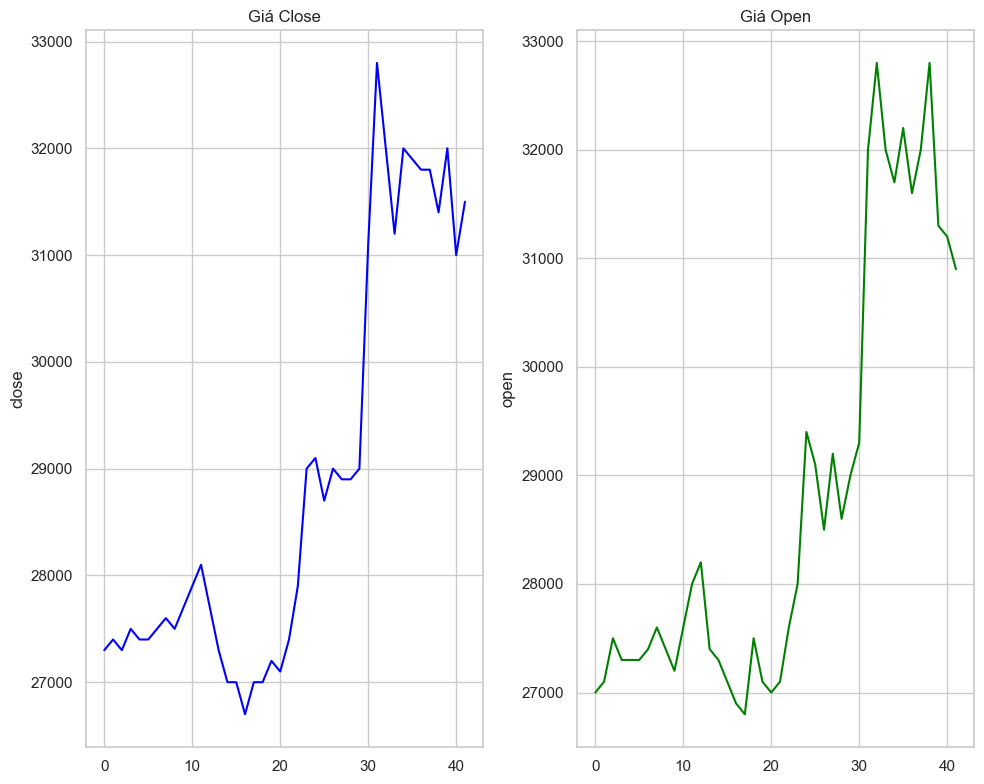

In [14]:
sns.set_theme(style="whitegrid", palette="pastel")
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

sns.lineplot(data=HTG_df['close'], ax=axes[0], color='blue')
axes[0].set_title('Giá Close')

sns.lineplot(data=HTG_df['open'], ax=axes[1], color='green')
axes[1].set_title('Giá Open')

plt.tight_layout()
plt.show()

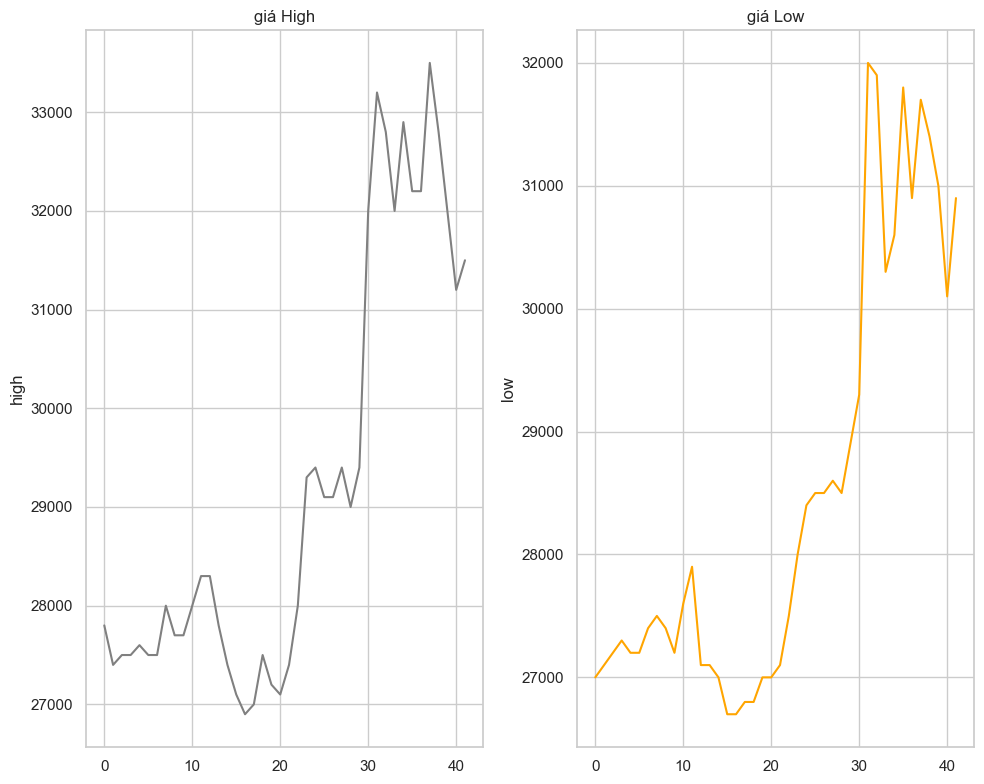

In [15]:
sns.set_theme(style="whitegrid", palette="pastel")
fig, axes = plt.subplots(1, 2, figsize=(10, 8))

sns.lineplot(data=HTG_df['high'], ax=axes[0], color='gray')
axes[0].set_title('giá High')

sns.lineplot(data=HTG_df['low'], ax=axes[1], color='orange')
axes[1].set_title('giá Low')

plt.tight_layout()
plt.show()

# Câu 8

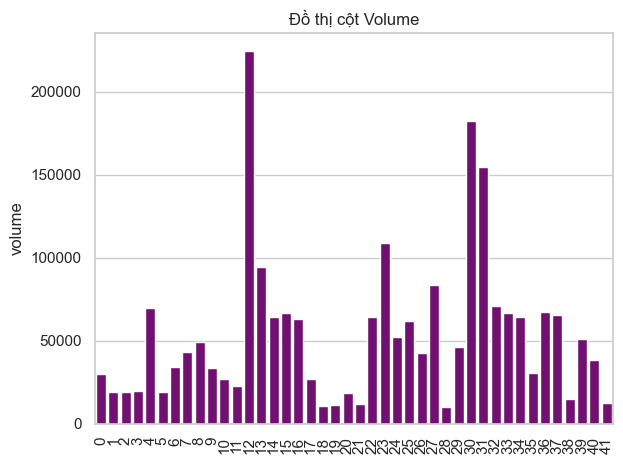

In [ ]:
sns.barplot(data = HTG_df['volume'], color = 'purple')
plt.xticks(rotation = 90)
plt.title('Đồ thị cột Volume')
plt.tight_layout()
plt.show()

# Câu 9

In [19]:
X = HTG_df['volume']
X = X.values.reshape(-1, 1) if isinstance(X, pd.Series) else X

y = HTG_df['close']
y = y.values if isinstance(y, pd.Series) else y

model = LinearRegression()
model.fit(X, y)

LinearRegression()

# Câu 10

In [21]:
new_volume = np.random.randint(HTG_df.describe()['volume']['min'], HTG_df.describe()['volume']['max'], size = 10)

y_pred = model.predict(new_volume.reshape(-1, 1))

print('Dự báo giá Close mới dựa trên Volume:')
new_df = pd.DataFrame({'random volume': new_volume,'predicted close': y_pred})
new_df

Dự báo giá Close mới dựa trên Volume:


,random volume,predicted close
0,123108,29602.634795
1,96362,29323.283006
2,178053,30176.514406
3,106290,29426.977187
4,191534,30317.318320
5,10626,28427.803120
6,68101,29028.107618
7,121642,29587.322983
8,160595,29994.172241
9,217492,30588.439749
